In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import figurefirst as fifi

plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


In [3]:
df = pd.read_parquet('../../../../../Data/Animal_Trajectory_Data/df_all_species.parquet')

# Slope bar plots

In [147]:
albatross= df[df.species =='albatross'].copy().sort_values('slope')
albatross.loc[3,'flow_condition'] = 'unknown1'
moth= df[df.species =='moths'].sort_values('slope')
shark= df[df.objid.isin(['shark_a', 'shark_d'])].sort_values('slope')



In [151]:
def get_bar_plot(df,col, ax=None):
    if ax==None:
        fig, ax = plt.subplots(figsize=(2,4))

    
    ax.bar(np.array([0,0.25]), df[col], align='center',width=0.15)
    
    # Iterate through bars and set color based on condition
    for i, bar in enumerate(ax.patches):
        if df['flow_condition'].iloc[i] == 'laminar':
            bar.set_color('#b83f3fff')
        if df['flow_condition'].iloc[i] == 'turbulent':
            bar.set_color('#bfd6e8ff')
        if df['flow_condition'].iloc[i] == 'stillair':
            bar.set_color('#084a72ff')    
        if df['flow_condition'].iloc[i] == 'unknown':
            bar.set_color('#8a7d89be')        
        if df['flow_condition'].iloc[i] == 'unknown1':
            bar.set_color('#201c20b8')      
    ax.set_ylim(0,int(np.ceil(df[col].max())))
    fifi.mpl_functions.adjust_spines(ax, ['left'], yticks =[0,int(np.ceil(df[col].max()))], spine_locations={'left':10, 'bottom':15},   tick_length=3, linewidth=1)
    fifi.mpl_functions.set_fontsize(ax, 6)
    plt.show()
    return ax

## moth

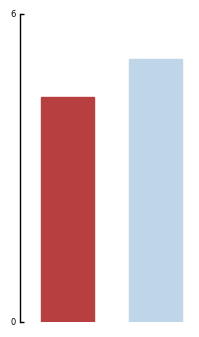

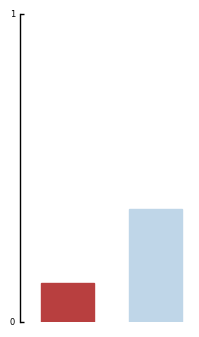

<Axes: >

In [105]:
get_bar_plot(moth, 'slope')
get_bar_plot(moth, 'axis_ratio')

## albatross

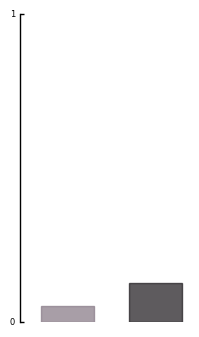

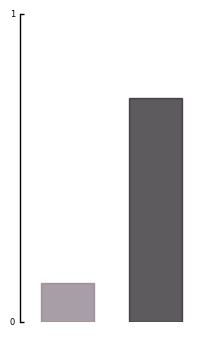

<Axes: >

In [160]:
get_bar_plot(albatross, 'slope')
get_bar_plot(albatross, 'axis_ratio')

## shark

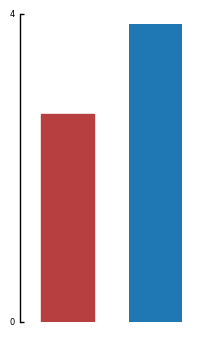

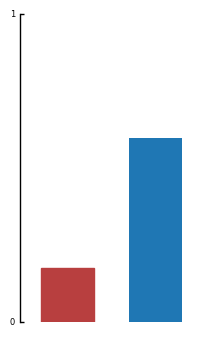

<Axes: >

In [163]:
get_bar_plot(shark, 'slope')
get_bar_plot(shark, 'axis_ratio')

# Slopes vs log(speed/length)

In [213]:
df[df['species']=='RL_agents']

,axis_ratio,slope,species,objid,body_length,group,flow_speed,movement_speed,reynolds,flow_condition,distance_travelled,visual_acuity_cpd,log(movementspeed/length)
9,0.699893,5.200235,RL_agents,rl_agent_c,0.004,aerial,0.5,2.858896,NaN,laminar,18.925888,NaN,NaN


In [251]:
df.loc[9,'body_length'] = 0.02

In [253]:
df['log(movementspeed/length)'] = np.log(df.movement_speed/df.body_length)

unknown 2.668928224545568
unknown 2.0638131107879745
trail 1.4808648414136796
trail 1.3183879692784046
unknown 3.010040121255532
None -3.1859706575132605
None -4.667200473127418


Text(0.5, 0, 'log(movementspeed/length)')

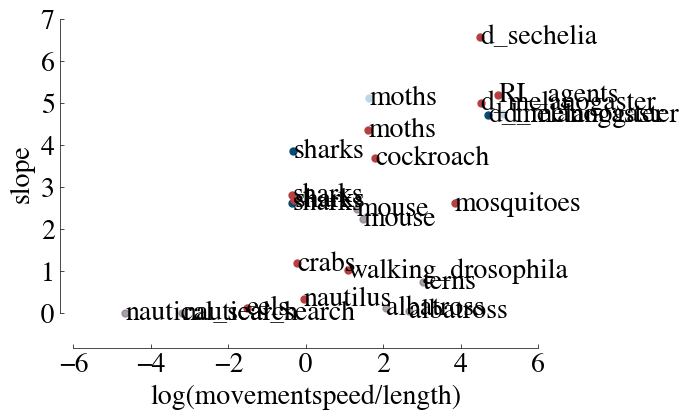

In [255]:

fig, ax = plt.subplots(figsize=(6,4))


col='log(movementspeed/length)'


for i in range(len(df)):
    point = df.iloc[i]
    if point['flow_condition']=='laminar':
        ax.plot(point[col],point['slope'], '.',markersize=10, color='#b83f3fff')
    elif point['flow_condition']=='stillair':
        ax.plot(point[col],point['slope'], '.',markersize=10, color='#084a72ff')
    elif point['flow_condition']=='still':
        ax.plot(point[col],point['slope'], '.',markersize=10, color='#084a72ff')    
    elif point['flow_condition']=='turbulent':
        ax.plot(point[col],point['slope'], '.',markersize=10, color='#bfd6e8ff')
    elif point['flow_condition']=='unsteady':
        ax.plot(point[col],point['slope'], '.',markersize=10, color='#bfd6e8ff')
    else:
        print(point['flow_condition'],point[col])
        ax.plot(point[col],point['slope'], '.',markersize=10,  color='#8a7d89be')
        
    ax.text(point[col], point['slope'],point['species'], 
           color='black', fontsize=2, ha='left', va='center')



fifi.mpl_functions.adjust_spines(ax, ['left','bottom'], yticks =[0,1,2,3,4,5,6,7], xticks=[-6,-4,-2,0,2,4,6],spine_locations={'left':10, 'bottom':15},   tick_length=3, linewidth=.5)

fifi.mpl_functions.set_fontsize(ax, 20)
ax.set_ylabel('slope')
ax.set_xlabel(col)
#ax.set_xlim(-0.01,1)
#ax.set_aspect(.15)
#fig.savefig('scatter_all2.svg', transparent=True)